Adaptation des notebooks pour analyser les données des cinq sujets

Importation et configuration

In [2]:
import os
import nibabel as nib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nilearn.maskers import NiftiLabelsMasker
from nilearn import datasets
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Configuration
base_path_template = "./ds003720"
subjects = ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005']
t_r = 2.0

atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, resolution_mm=2)
masker = NiftiLabelsMasker(labels_img=atlas.maps, standardize=True, t_r=t_r)
print("Atlas et masker chargés")

[fetch_atlas_schaefer_2018] Dataset found in /home/etudiants/nilearn_data/schaefer_2018

Atlas et masker chargés


Extraction des données d'entrainnement

In [3]:
# Séparer Training et Test
X_train_global, y_train_global, s_train_global = [], [], []
X_test_global, y_test_global, s_test_global = [], [], []

print("Extraction Training (entraînement)...")
for subject in subjects:
    base_path = f"{base_path_template}/{subject}/func"
    n_runs = 12  # Training = 12 runs
    subject_X, subject_y = [], []

    for run in tqdm(range(1, n_runs + 1), desc=f"{subject}-Training"):
        run_str = f"run-0{run}"
        bold_file = f"{base_path}/{subject}_task-Training_{run_str}_bold.nii"
        events_file = f"{base_path}/{subject}_task-Training_{run_str}_events.tsv"

        if not (os.path.exists(bold_file) and os.path.exists(events_file)):
            continue

        func_img = nib.load(bold_file)
        events = pd.read_csv(events_file, sep="\t")
        roi_ts = masker.fit_transform(func_img)

        for _, row in events.iterrows():
            onset, duration, genre = row['onset'], row['duration'], row['genre']
            start_vol = int(onset / t_r)
            end_vol = int((onset + duration) / t_r)
            trial_ts = roi_ts[start_vol:end_vol, :]

            if trial_ts.shape[0] < 2:
                continue

            conn = np.corrcoef(trial_ts.T)
            flat = conn[np.triu_indices_from(conn, k=1)]

            if len(flat) == 4950 and not np.isnan(flat).any():
                subject_X.append(flat)
                subject_y.append(genre)

    print(f"{subject}-Training: {len(subject_X)} trials")
    X_train_global.extend(subject_X)
    y_train_global.extend(subject_y)
    s_train_global.extend([subject] * len(subject_X))



Extraction Training (entraînement)...


sub-001-Training:   0%|                                                              | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_593/321919739.py:21: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.float32(4.0), np.float32(54.0)}. Label image only contains 99 labels (including background).
  roi_ts = masker.fit_transform(func_img)
/tmp/ipykernel_593/321919739.py:21: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  roi_ts = masker.fit_transform(func_img)
sub-001-Training:   8%|████▌                                                 | 1/12 [00:18<03:20, 18.19s/it]/tmp/ipykernel_593/321919739.py:21: UserWarning: After resampling the label i

sub-001-Training: 41 trials


sub-002-Training:   0%|                                                              | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_593/321919739.py:21: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  roi_ts = masker.fit_transform(func_img)
sub-002-Training:   8%|████▌                                                 | 1/12 [00:17<03:14, 17.72s/it]/tmp/ipykernel_593/321919739.py:21: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning

sub-002-Training: 369 trials


...

sub-003-Training: 41 trials


sub-004-Training:   0%|                                                              | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_593/321919739.py:21: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  roi_ts = masker.fit_transform(func_img)
sub-004-Training:   8%|████▌                                                 | 1/12 [00:17<03:11, 17.37s/it]/tmp/ipykernel_593/321919739.py:21: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning

sub-004-Training: 328 trials


sub-005-Training:   0%|                                                              | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_593/321919739.py:21: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  roi_ts = masker.fit_transform(func_img)
sub-005-Training:   8%|████▌                                                 | 1/12 [00:18<03:19, 18.16s/it]/tmp/ipykernel_593/321919739.py:21: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning

sub-005-Training: 205 trials


Extraction des données test

In [4]:
print("\nExtraction Test (évaluation)...")

for subject in subjects:
    base_path = f"{base_path_template}/{subject}/func"
    n_runs = 6  # Test = 6 runs
    subject_X, subject_y = [], []

    for run in tqdm(range(1, n_runs + 1), desc=f"{subject}-Test"):
        run_str = f"run-0{run}"
        bold_file = f"{base_path}/{subject}_task-Test_{run_str}_bold.nii"
        events_file = f"{base_path}/{subject}_task-Test_{run_str}_events.tsv"

        if not (os.path.exists(bold_file) and os.path.exists(events_file)):
            continue

        func_img = nib.load(bold_file)
        events = pd.read_csv(events_file, sep="\t")
        roi_ts = masker.fit_transform(func_img)

        for _, row in events.iterrows():
            onset, duration, genre = row['onset'], row['duration'], row['genre']
            start_vol = int(onset / t_r)
            end_vol = int((onset + duration) / t_r)
            trial_ts = roi_ts[start_vol:end_vol, :]

            if trial_ts.shape[0] < 2:
                continue

            conn = np.corrcoef(trial_ts.T)
            flat = conn[np.triu_indices_from(conn, k=1)]

            if len(flat) == 4950 and not np.isnan(flat).any():
                subject_X.append(flat)
                subject_y.append(genre)

    print(f"{subject}-Test: {len(subject_X)} trials")
    X_test_global.extend(subject_X)
    y_test_global.extend(subject_y)
    s_test_global.extend([subject] * len(subject_X))


Extraction Test (évaluation)...


sub-001-Test:   0%|                                                                   | 0/6 [00:00<?, ?it/s]/tmp/ipykernel_593/4017672499.py:18: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.float32(4.0), np.float32(54.0)}. Label image only contains 99 labels (including background).
  roi_ts = masker.fit_transform(func_img)
/tmp/ipykernel_593/4017672499.py:18: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  roi_ts = masker.fit_transform(func_img)
sub-001-Test:  17%|█████████▊                                                 | 1/6 [00:18<01:31, 18.34s/it]/tmp/ipykernel_593/4017672499.py:18: UserWarning: After resampling the labe

sub-001-Test: 82 trials


sub-002-Test:   0%|                                                                   | 0/6 [00:00<?, ?it/s]/tmp/ipykernel_593/4017672499.py:18: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  roi_ts = masker.fit_transform(func_img)
sub-002-Test:  17%|█████████▊                                                 | 1/6 [00:18<01:30, 18.05s/it]/tmp/ipykernel_593/4017672499.py:18: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warni

sub-002-Test: 246 trials


...

sub-003-Test: 82 trials


sub-004-Test:   0%|                                                                   | 0/6 [00:00<?, ?it/s]/tmp/ipykernel_593/4017672499.py:18: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  roi_ts = masker.fit_transform(func_img)
sub-004-Test:  17%|█████████▊                                                 | 1/6 [00:17<01:27, 17.44s/it]/tmp/ipykernel_593/4017672499.py:18: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warni

sub-004-Test: 164 trials


sub-005-Test:   0%|                                                                   | 0/6 [00:00<?, ?it/s]/tmp/ipykernel_593/4017672499.py:18: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  roi_ts = masker.fit_transform(func_img)
sub-005-Test:  17%|█████████▊                                                 | 1/6 [00:17<01:28, 17.66s/it]/tmp/ipykernel_593/4017672499.py:18: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warni

sub-005-Test: 164 trials


Convertir en numpy arrays

In [5]:
# Convertir en arrays
X_train = np.array(X_train_global)
y_train = np.array(y_train_global)
s_train = np.array(s_train_global)

X_test = np.array(X_test_global)
y_test = np.array(y_test_global)
s_test = np.array(s_test_global)

print(f"\nTraining: {X_train.shape[0]} trials")
print(f"Test: {X_test.shape[0]} trials")
print(f"Genres: {sorted(np.unique(y_train))}")


Training: 984 trials
Test: 738 trials
Genres: [np.str_("'blues'"), np.str_("'classical'"), np.str_("'country'"), np.str_("'disco'"), np.str_("'hiphop'"), np.str_("'jazz'"), np.str_("'metal'"), np.str_("'pop'"), np.str_("'reggae'"), np.str_("'rock'"), np.str_("classical'"), np.str_("jazz'"), np.str_("metal'")]


Entrainer le modèle avec les données d'entrainement et prédiction sur les données de tests

In [6]:
# Entraîner sur Training
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Prédire sur Test
y_pred = clf.predict(X_test)

# Performance globale sur Test
global_acc = accuracy_score(y_test, y_pred)
print(f"\nGlobal accuracy (Training→Test): {global_acc:.3f}")
print(classification_report(y_test, y_pred))


Global accuracy (Training→Test): 0.091
              precision    recall  f1-score   support

     'blues'       0.10      0.15      0.12        72
 'classical'       0.10      0.08      0.09        72
   'country'       0.13      0.17      0.15        72
     'disco'       0.07      0.07      0.07        72
    'hiphop'       0.07      0.06      0.06        72
      'jazz'       0.11      0.09      0.10        76
     'metal'       0.08      0.08      0.08        75
       'pop'       0.11      0.08      0.09        75
    'reggae'       0.07      0.07      0.07        80
      'rock'       0.06      0.06      0.06        72

    accuracy                           0.09       738
   macro avg       0.09      0.09      0.09       738
weighted avg       0.09      0.09      0.09       738



Matrice de confusion pour tous les sujets

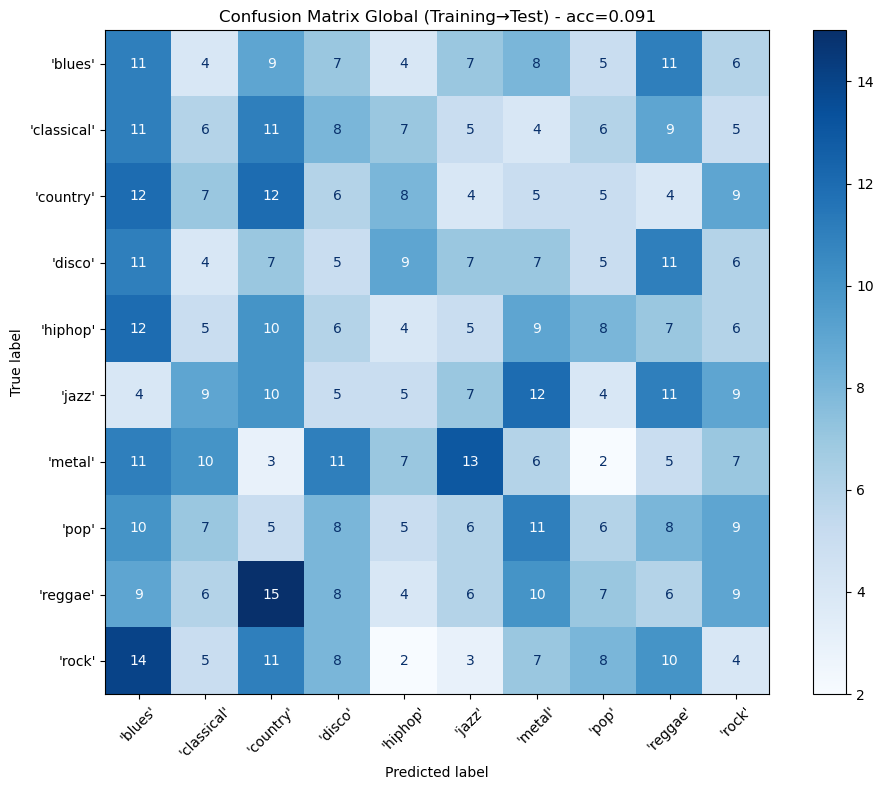

In [7]:
# Matrice de confusion globale
labels = sorted(np.unique(y_test))
cm_global = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_global, display_labels=labels).plot(
    ax=ax, xticks_rotation=45, cmap='Blues', colorbar=True, values_format='d'
)
ax.set_title(f'Confusion Matrix Global (Training→Test) - acc={global_acc:.3f}')
plt.tight_layout()
plt.show()

Matrice de confusion par sujet sur les données test

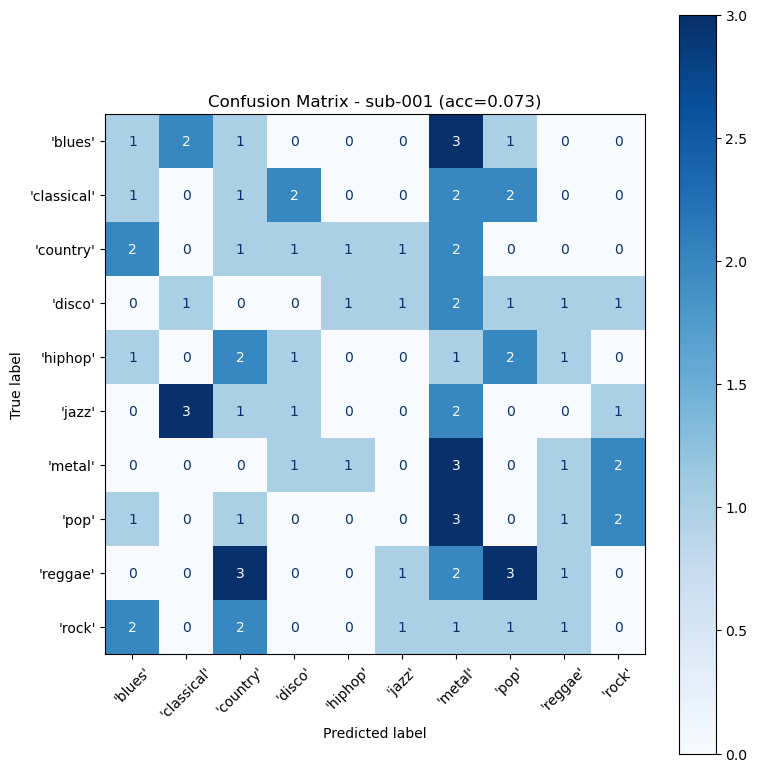

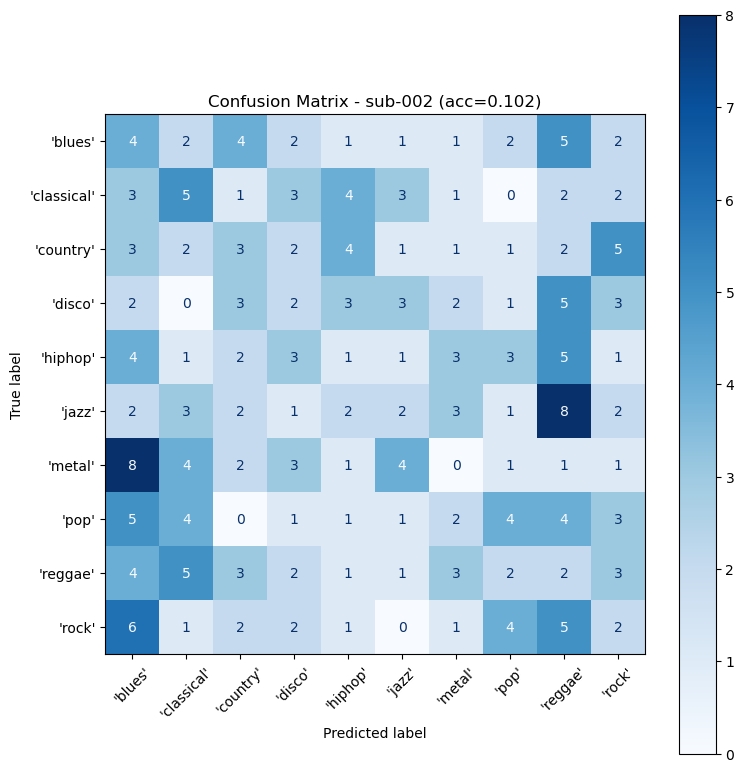

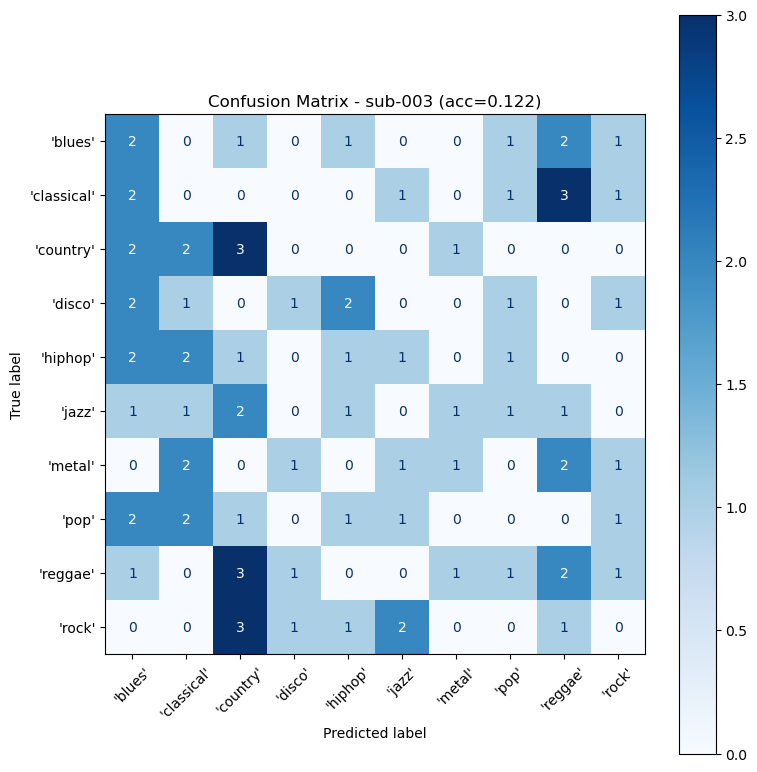

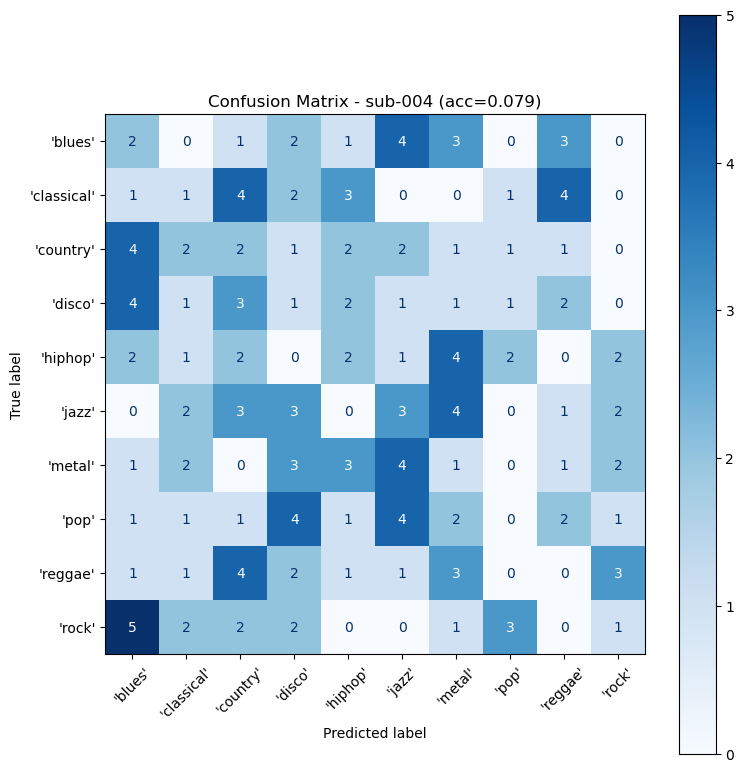

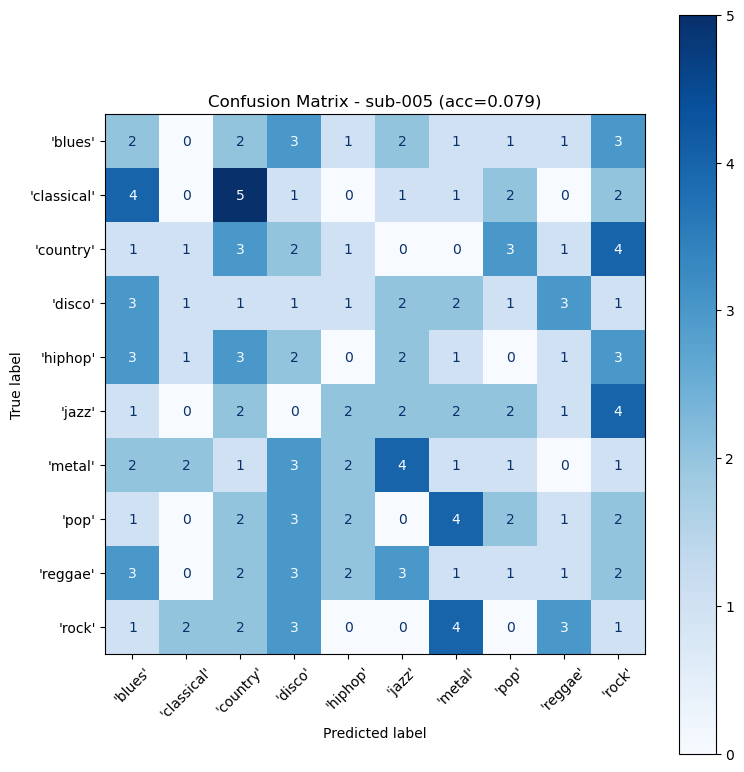

In [8]:
# Matrice de confusion PAR SUJET
subject_metrics = []
for sub in sorted(np.unique(s_test)):
    mask = s_test == sub
    if mask.sum() == 0:
        continue

    cm = confusion_matrix(y_test[mask], y_pred[mask], labels=labels)
    acc = accuracy_score(y_test[mask], y_pred[mask])
    subject_metrics.append({'subject': sub, 'n_trials': int(mask.sum()), 'accuracy': acc})

    fig, ax = plt.subplots(figsize=(8, 8))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
        ax=ax, xticks_rotation=45, cmap='Blues', colorbar=True, values_format='d'
    )
    ax.set_title(f'Confusion Matrix - {sub} (acc={acc:.3f})')
    plt.tight_layout()
    plt.savefig(f'cm_{sub}.png', dpi=150, bbox_inches='tight')
    plt.show()